# Лекция. Полиномиальная регрессия

В этой работе мы рассмотрим полиномиальную регрессию как способ моделировать
нелинейные зависимости в агропромышленном комплексе (АПК), сохраняя простоту
и интерпретируемость линейных моделей.

**Цели ноутбука:**

- напомнить идею линейной регрессии и её ограничения;
- ввести понятие полиномиальной регрессии как линейной модели на расширенном
  наборе признаков;
- на примере зависимости "доза удобрения — урожайность" показать разницу
  между линейной и полиномиальными моделями степени 2 и 3;
- проиллюстрировать переобучение при увеличении степени полинома;
- обсудить интерпретацию результатов с точки зрения задач АПК.


## 1. Напоминание: линейная регрессия и её ограничения

Модель простой линейной регрессии описывает зависимость отклика $y$
от одного признака $x$ в виде
$$
 y = w_0 + w_1 x + \varepsilon,
$$
где

- $x$ — один признак (фактор),
- $y$ — отклик (результат),
- $w_0, w_1$ — коэффициенты модели,
- $\varepsilon$ — случайная ошибка.

Геометрически это прямая линия на плоскости $(x, y).$ Если реальная
зависимость между фактором и результатом сильно криволинейна, то прямая
линия не сможет хорошо описать данные: модель будет **систематически
ошибаться**.

В задачах АПК такие нелинейные зависимости встречаются часто. Например:

- урожайность от дозы удобрения: рост → максимум → падение;
- урожайность от влагообеспечения: и дефицит, и избыток влаги вредны;
- отклик растений на температуру: есть оптимальная зона и снижение
  при экстремально низких/высоких температурах.

Мы хотим получить модель, которая:

- остаётся достаточно простой и интерпретируемой;
- способна описывать **кривые** зависимости;
- легко реализуется средствами Python и `scikit-learn`.


## 2. Подготовка окружения

Подключим необходимые библиотеки.

In [22]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

## 3. Синтетический пример: зависимость урожайности от дозы удобрения

Для наглядности создадим искусственный набор данных, отражающий типичную
агрохимическую ситуацию:

- при малых дозах удобрения урожайность низкая (дефицит элемента);
- при умеренных дозах — растёт и достигает максимума;
- при чрезмерных дозах — снижается (переудобрение, угнетение растений).

Такую форму удобно описывать квадратичной функцией (параболой,
обращённой ветвями вниз), к которой мы добавим случайный шум.


In [23]:
rng = np.random.default_rng(42)

# X — доза удобрения, кг/га
X = np.linspace(0, 200, 40).reshape(-1, 1)

# "Истинная" квадратичная зависимость без шума (ц/га)
y_true = -0.005 * X**2 + 1.2 * X + 20

# Добавляем шум, имитирующий влияние погоды, неоднородности почвы и т.п.
noise = rng.normal(0, 10, size=X.shape)
y = (y_true + noise).ravel()

X.shape, y.shape

((40, 1), (40,))

Построим график с исходными данными (наблюдаемая урожайность) и
истинной кривой без шума.

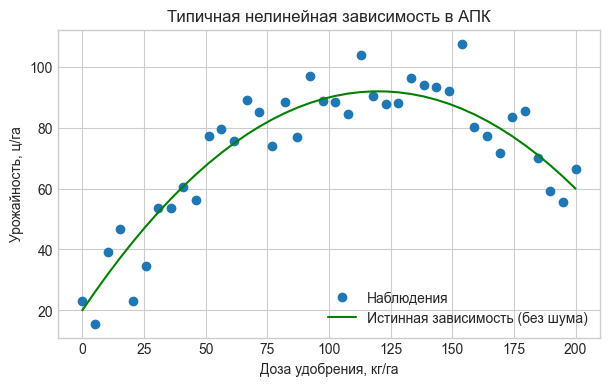

In [24]:
plt.figure(figsize=(7, 4))
plt.scatter(X, y, label='Наблюдения')
plt.plot(X, y_true, color='green', label='Истинная зависимость (без шума)')
plt.xlabel('Доза удобрения, кг/га')
plt.ylabel('Урожайность, ц/га')
plt.title('Типичная нелинейная зависимость в АПК')
plt.legend()
plt.show()

На графике видно, что точки группируются вокруг кривой с максимумом.
Простая прямая линия не сможет хорошо описать такую форму зависимости.

Далее мы сравним линейную регрессию с полиномиальными моделями.


## 4. Базовая модель: линейная регрессия

Сначала обучим обычную линейную регрессию на этих данных. Это будет
"точка отсчёта", с которой мы дальше будем сравнивать полиномиальные
модели.

Разделим данные на обучающую и тестовую выборки (например, 75\% / 25\%),
чтобы оценивать качество модели на данных, не участвовавших в обучении.

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

len(X_train), len(X_test)

(30, 10)

Обучим модель `LinearRegression` и посмотрим на коэффициенты и качество
по метрикам MSE и $R^2.$

In [26]:
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

y_pred_lin = lin_model.predict(X_test)
mse_lin = mean_squared_error(y_test, y_pred_lin)
r2_lin = r2_score(y_test, y_pred_lin)

print('Линейная модель:')
print('  w0 (intercept) =', lin_model.intercept_)
print('  w1 (slope)     =', lin_model.coef_)
print('  MSE =', mse_lin)
print('  R^2 =', r2_lin)

Линейная модель:
  w0 (intercept) = 49.23386068001628
  w1 (slope)     = [0.24169762]
  MSE = 439.17952440038516
  R^2 = 0.043556785344083804


Коэффициент $w_1$ описывает, как по модели меняется урожайность при
изменении дозы удобрения на 1 кг/га: модель предполагает **линейный** рост
или падение без учета существования оптимума.

Метрики MSE и $R^2$ дают количественную оценку качества, но чтобы увидеть
форму ошибки, построим график с линией линейной регрессии.


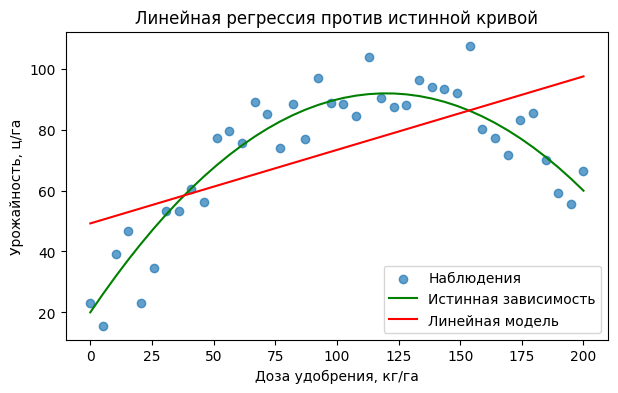

In [14]:
X_line = np.linspace(0, 200, 200).reshape(-1, 1)
y_line_lin = lin_model.predict(X_line)

plt.figure(figsize=(7, 4))
plt.scatter(X, y, alpha=0.7, label='Наблюдения')
plt.plot(X, y_true, color='green', label='Истинная зависимость')
plt.plot(X_line, y_line_lin, color='red', label='Линейная модель')
plt.xlabel('Доза удобрения, кг/га')
plt.ylabel('Урожайность, ц/га')
plt.title('Линейная регрессия против истинной кривой')
plt.legend()
plt.show()

Линия линейной регрессии не совпадает с истинной кривой: на малых дозах
она систематически завышает/занижает урожай, в окрестности оптимума — не
попадает в вершину, на больших дозах — тоже даёт значимую ошибку.

Это пример **систематической ошибки формы модели** (model bias):
модель слишком проста для описания реального процесса.


## 5. Полиномиальная регрессия: идея и реализация

Чтобы описать кривую, добавим в модель степени исходного признака.
В одномерном случае полиномиальная регрессия степени $d$ имеет вид:
$$
 y = w_0 + w_1 x + w_2 x^2 + \dots + w_d x^d + \varepsilon.
$$

Ключевое наблюдение:

- по коэффициентам $w_i$ модель по-прежнему **линейная**;
- нелинейность возникает только по исходной переменной $x$;
- такую модель можно обучать теми же методами, что и обычную линейную
  регрессию.

В библиотеке `scikit-learn` полиномиальные признаки удобно генерировать
через класс `PolynomialFeatures`.


### 5.1. Полиномиальные признаки степени 2

Начнём с квадратичной модели (степень 2).

Преобразуем исходный признак $x$ в вектор признаков $[x, x^2]$ и обучим
линейную регрессию на этом новом пространстве.


In [27]:
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly2 = poly2.fit_transform(X_train)
X_test_poly2 = poly2.transform(X_test)

print('Пример исходного X:', X_train[0])
print('После PolynomialFeatures(degree=2):', X_train_poly2[0])

Пример исходного X: [128.20512821]
После PolynomialFeatures(degree=2): [  128.20512821 16436.55489809]


Видно, что к исходному значению $x$ добавился признак $x^2$. Теперь
обучим модель и оценим её качество.


In [28]:
model_poly2 = LinearRegression()
model_poly2.fit(X_train_poly2, y_train)

y_pred_poly2 = model_poly2.predict(X_test_poly2)
mse_poly2 = mean_squared_error(y_test, y_pred_poly2)
r2_poly2 = r2_score(y_test, y_pred_poly2)

print('Полиномиальная регрессия степени 2:')
print('  Коэффициенты:', model_poly2.coef_)
print('  intercept =', model_poly2.intercept_)
print('  MSE =', mse_poly2)
print('  R^2 =', r2_poly2)

Полиномиальная регрессия степени 2:
  Коэффициенты: [ 1.25914585 -0.00528637]
  intercept = 19.00364532540486
  MSE = 64.08001125906868
  R^2 = 0.8604468365243368


Сравните значения MSE и $R^2$ с линейной моделью.
Обычно квадратичная модель значительно лучше приближает истинную кривую.

Знак коэффициента при $x^2$ должен быть отрицательным (ветви параболы
направлены вниз), что согласуется с идеей наличия оптимальной дозы удобрения.

По оценённым коэффициентам $w_1, w_2$ можно найти положение максимума:
$$
 N^* = -\frac{w_1}{2 w_2}.
$$
Это оценка оптимальной дозы удобрения с точки зрения модели.


### 5.2. Полиномиальная регрессия степени 3

Рассмотрим модель с ещё большей гибкостью — добавим кубический член
(степень 3).

In [29]:
poly3 = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly3 = poly3.fit_transform(X_train)
X_test_poly3 = poly3.transform(X_test)

model_poly3 = LinearRegression()
model_poly3.fit(X_train_poly3, y_train)

y_pred_poly3 = model_poly3.predict(X_test_poly3)
mse_poly3 = mean_squared_error(y_test, y_pred_poly3)
r2_poly3 = r2_score(y_test, y_pred_poly3)

print('Полиномиальная регрессия степени 3:')
print('  MSE =', mse_poly3)
print('  R^2 =', r2_poly3)

Полиномиальная регрессия степени 3:
  MSE = 63.720624503170356
  R^2 = 0.8612295074026877


Снова сравните метрики с предыдущими моделями.

Иногда степень 3 даёт небольшой прирост качества, иногда — почти не
улучшает результат по сравнению с квадратичной моделью. Важно понимать,
что с ростом степени полинома растёт и риск переобучения.


### 5.3. Визуальное сравнение моделей степеней 1, 2 и 3

Построим на одном графике:

- линейную модель (степень 1),
- полиномиальную модель степени 2,
- полиномиальную модель степени 3.


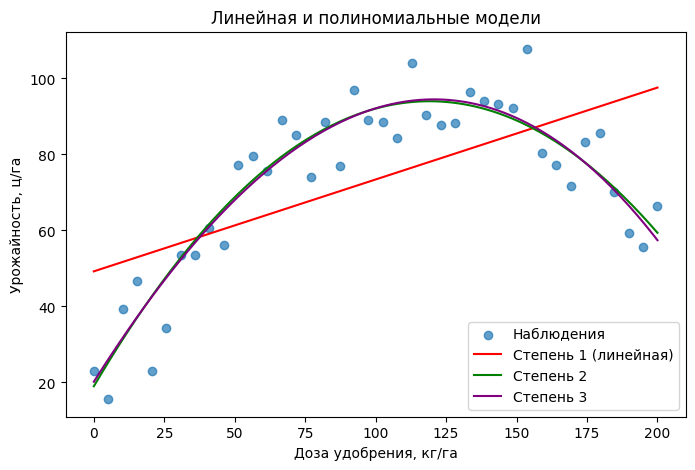

In [19]:
X_line_poly2 = poly2.transform(X_line)
y_line_poly2 = model_poly2.predict(X_line_poly2)

X_line_poly3 = poly3.transform(X_line)
y_line_poly3 = model_poly3.predict(X_line_poly3)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.7, label='Наблюдения')
plt.plot(X_line, y_line_lin,  color='red',    label='Степень 1 (линейная)')
plt.plot(X_line, y_line_poly2, color='green',  label='Степень 2')
plt.plot(X_line, y_line_poly3, color='purple', label='Степень 3')
plt.xlabel('Доза удобрения, кг/га')
plt.ylabel('Урожайность, ц/га')
plt.title('Линейная и полиномиальные модели')
plt.legend()
plt.show()

По графику можно обсудить:

- какая из моделей лучше всего визуально приближает истинную кривую;
- нет ли у модели степени 3 "излишней гибкости" (например, странных
  изгибов на краях диапазона);
- соответствует ли форма кривой агрономической логике (наличие оптимума,
  снижение при чрезмерных дозах и т.п.).


### 5.3.1 Визуальное сравнение моделей степеней 1, 2 и 4

Построим на одном графике:

- линейную модель (степень 1),
- полиномиальную модель степени 2,
- полиномиальную модель степени 4.


In [31]:
poly4 = PolynomialFeatures(degree=4, include_bias=False)
X_train_poly4 = poly4.fit_transform(X_train)
X_test_poly4 = poly4.transform(X_test)

model_poly4 = LinearRegression()
model_poly4.fit(X_train_poly4, y_train)

y_pred_poly4 = model_poly4.predict(X_test_poly4)
mse_poly4 = mean_squared_error(y_test, y_pred_poly4)
r2_poly4 = r2_score(y_test, y_pred_poly4)

print('Полиномиальная регрессия степени 4:')
print('  MSE =', mse_poly4)
print('  R^2 =', r2_poly4)

Полиномиальная регрессия степени 4:
  MSE = 71.4818363122674
  R^2 = 0.8443271748486982


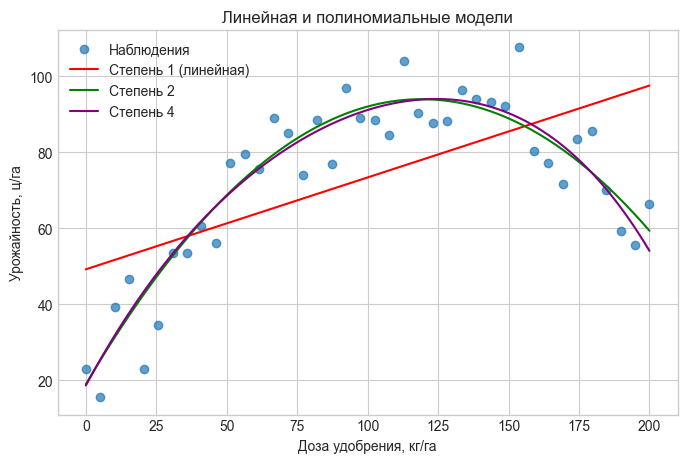

In [33]:
X_line_poly2 = poly2.transform(X_line)
y_line_poly2 = model_poly2.predict(X_line_poly2)

X_line_poly4 = poly4.transform(X_line)
y_line_poly4 = model_poly4.predict(X_line_poly4)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.7, label='Наблюдения')
plt.plot(X_line, y_line_lin,  color='red',    label='Степень 1 (линейная)')
plt.plot(X_line, y_line_poly2, color='green',  label='Степень 2')
plt.plot(X_line, y_line_poly4, color='purple', label='Степень 4')
plt.xlabel('Доза удобрения, кг/га')
plt.ylabel('Урожайность, ц/га')
plt.title('Линейная и полиномиальные модели')
plt.legend()
plt.show()

### 5.3.2 Визуальное сравнение моделей степеней 1, 2 и 5

Построим на одном графике:

- линейную модель (степень 1),
- полиномиальную модель степени 2,
- полиномиальную модель степени 5.


In [39]:
poly5 = PolynomialFeatures(degree=5, include_bias=False)
X_train_poly5 = poly5.fit_transform(X_train)
X_test_poly5 = poly5.transform(X_test)

model_poly5 = LinearRegression()
model_poly5.fit(X_train_poly5, y_train)

y_pred_poly5 = model_poly5.predict(X_test_poly5)
mse_poly5 = mean_squared_error(y_test, y_pred_poly5)
r2_poly5 = r2_score(y_test, y_pred_poly5)

print('Полиномиальная регрессия степени 5:')
print('  MSE =', mse_poly5)
print('  R^2 =', r2_poly5)

Полиномиальная регрессия степени 5:
  MSE = 93.36001290748666
  R^2 = 0.7966809791793743


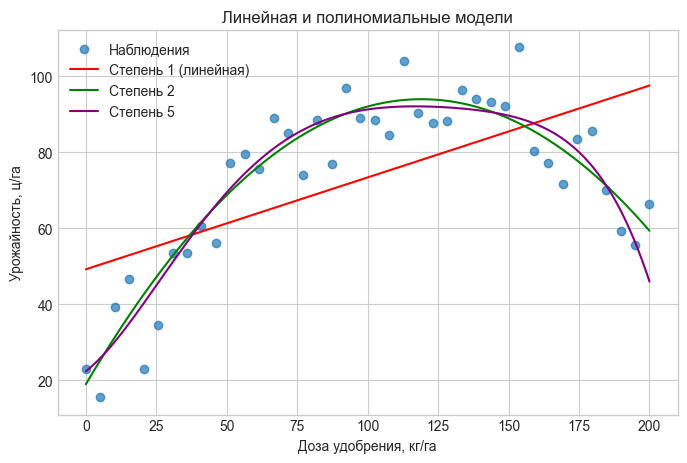

In [40]:
X_line_poly2 = poly2.transform(X_line)
y_line_poly2 = model_poly2.predict(X_line_poly2)

X_line_poly5 = poly5.transform(X_line)
y_line_poly5 = model_poly5.predict(X_line_poly5)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.7, label='Наблюдения')
plt.plot(X_line, y_line_lin,  color='red',    label='Степень 1 (линейная)')
plt.plot(X_line, y_line_poly2, color='green',  label='Степень 2')
plt.plot(X_line, y_line_poly5, color='purple', label='Степень 5')
plt.xlabel('Доза удобрения, кг/га')
plt.ylabel('Урожайность, ц/га')
plt.title('Линейная и полиномиальные модели')
plt.legend()
plt.show()

### 5.3.2 Визуальное сравнение моделей степеней 1, 2 и 10

Построим на одном графике:

- линейную модель (степень 1),
- полиномиальную модель степени 2,
- полиномиальную модель степени 10.


In [43]:
poly10 = PolynomialFeatures(degree=10, include_bias=False)
X_train_poly10 = poly10.fit_transform(X_train)
X_test_poly10 = poly10.transform(X_test)

model_poly10 = LinearRegression()
model_poly10.fit(X_train_poly10, y_train)

y_pred_poly10 = model_poly10.predict(X_test_poly10)
mse_poly10 = mean_squared_error(y_test, y_pred_poly10)
r2_poly10 = r2_score(y_test, y_pred_poly10)

print('Полиномиальная регрессия степени 5:')
print('  MSE =', mse_poly10)
print('  R^2 =', r2_poly10)

Полиномиальная регрессия степени 5:
  MSE = 147.20518326674738
  R^2 = 0.6794172066881139


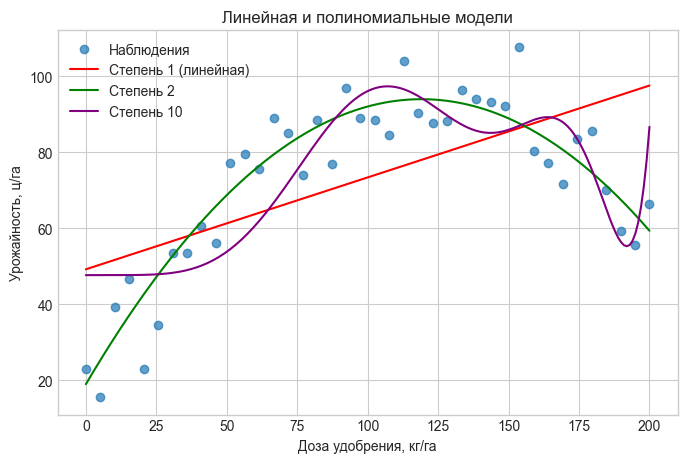

In [44]:
X_line_poly2 = poly2.transform(X_line)
y_line_poly2 = model_poly2.predict(X_line_poly2)

X_line_poly10 = poly10.transform(X_line)
y_line_poly10 = model_poly10.predict(X_line_poly10)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.7, label='Наблюдения')
plt.plot(X_line, y_line_lin,  color='red',    label='Степень 1 (линейная)')
plt.plot(X_line, y_line_poly2, color='green',  label='Степень 2')
plt.plot(X_line, y_line_poly10, color='purple', label='Степень 10')
plt.xlabel('Доза удобрения, кг/га')
plt.ylabel('Урожайность, ц/га')
plt.title('Линейная и полиномиальные модели')
plt.legend()
plt.show()

## 6. Переобучение и выбор степени полинома

Чем выше степень полинома, тем более гибкой становится модель: она может
лучше подстроиться под имеющиеся точки. При этом растёт риск переобучения:
модель начинает подгоняться под шум, а не под общую закономерность.

Чтобы это увидеть, изучим, как меняются ошибки на обучающей и тестовой
выборках при увеличении степени полинома.


In [20]:
degrees = range(1, 10)
mse_train, mse_test = [], []
r2_train, r2_test = [], []

for d in degrees:
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_tr_poly = poly.fit_transform(X_train)
    X_te_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_tr_poly, y_train)

    y_tr_pred = model.predict(X_tr_poly)
    y_te_pred = model.predict(X_te_poly)

    mse_train.append(mean_squared_error(y_train, y_tr_pred))
    mse_test.append(mean_squared_error(y_test, y_te_pred))
    r2_train.append(r2_score(y_train, y_tr_pred))
    r2_test.append(r2_score(y_test, y_te_pred))

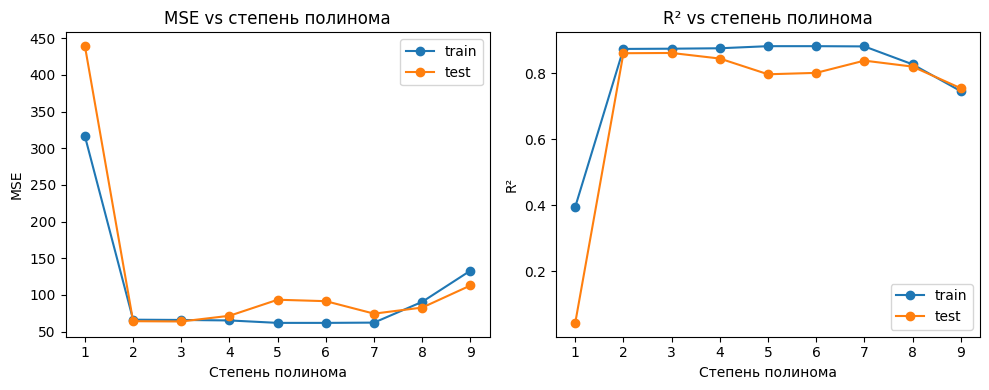

In [21]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(degrees, mse_train, marker='o', label='train')
plt.plot(degrees, mse_test, marker='o', label='test')
plt.xlabel('Степень полинома')
plt.ylabel('MSE')
plt.title('MSE vs степень полинома')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(degrees, r2_train, marker='o', label='train')
plt.plot(degrees, r2_test, marker='o', label='test')
plt.xlabel('Степень полинома')
plt.ylabel('R²')
plt.title('R² vs степень полинома')
plt.legend()

plt.tight_layout()
plt.show()

Интерпретация графиков:

- ошибка на обучающей выборке (train MSE) обычно **монотонно падает**
  с ростом степени: модель всё лучше подстраивается под обучающие точки;
- ошибка на тестовой выборке (test MSE) сначала снижается, но после
  некоторой степени перестаёт уменьшаться и может начать расти — это
  проявление **переобучения**;
- графики \(R^2\) ведут себя противоположно MSE: на обучении растут,
  на тесте после оптимальной степени могут снижаться.

Выбор степени полинома связан с поиском баланса между сложностью модели
и её способностью обобщать (bias–variance tradeoff). Практически степень
выбирают по минимальной тестовой ошибке или по результатам кросс-валидации.


## 7. Заключение и связь с задачами АПК

В этом ноутбуке мы:

- напомнили модель линейной регрессии и увидели её ограничения на примере
  криволинейной зависимости "доза удобрения — урожайность";
- построили полиномиальные модели степеней 2 и 3 и увидели, что они лучше
  описывают реальную форму зависимости;
- с помощью графиков ошибок по степени полинома проиллюстрировали явление
  переобучения;
- обсудили, как выбирать степень полинома и как интерпретировать результаты
  с агрономической точки зрения (наличие оптимальной дозы, эффект
  переудобрения и т.п.).

Полиномиальная регрессия — простой, но мощный инструмент, который
позволяет расширить возможности линейных моделей и является важным
переходным шагом к более общим нелинейным методам (деревья решений,
ансамбли, нейронные сети).
